Đã vẽ xong biểu đồ: bieu_do_thuc_nghiem_24h.png


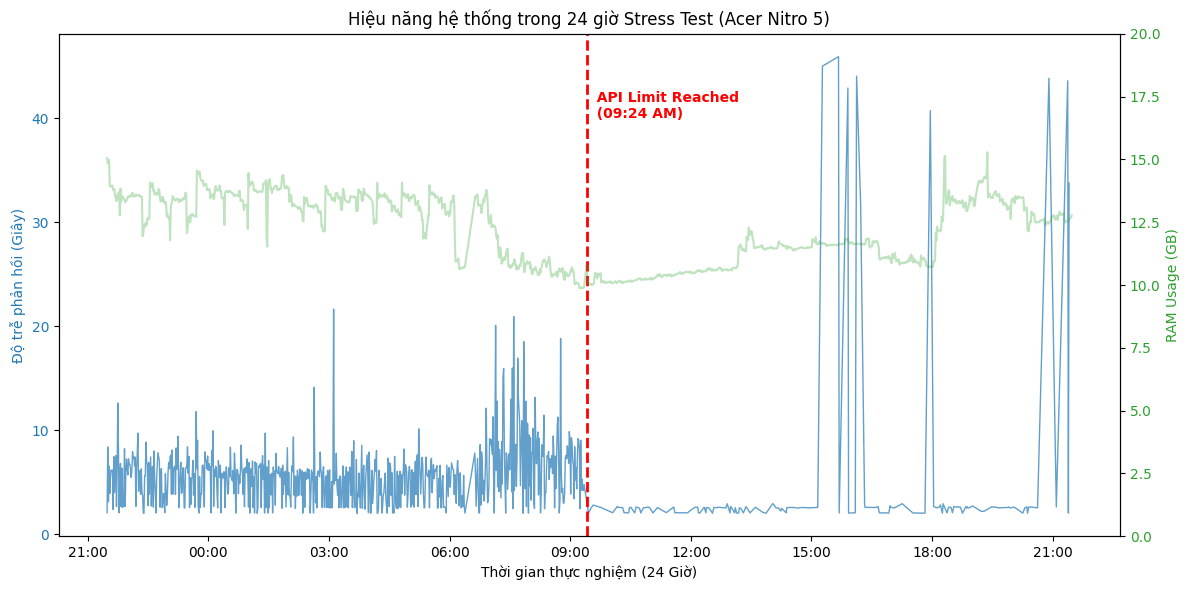

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# 1. Đọc dữ liệu
df = pd.read_csv('ket_qua_test_thuc_nghiem.csv')
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

# 2. Thiết lập biểu đồ
fig, ax1 = plt.subplots(figsize=(12, 6))

# --- VẼ ĐỘ TRỄ (LATENCY) ---
# Chỉ lấy các điểm SUCCESS để vẽ đường latency thực tế
success_data = df[df['Status'] == 'SUCCESS']
ax1.plot(success_data['Timestamp'], success_data['Latency(s)'], 
         color='tab:blue', alpha=0.7, label='Latency (s)', linewidth=1)
ax1.set_xlabel('Thời gian thực nghiệm (24 Giờ)')
ax1.set_ylabel('Độ trễ phản hồi (Giây)', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

# Đánh dấu khu vực bị TIMEOUT (Giai đoạn 2)
# Tìm điểm bắt đầu lỗi
first_error = df[df['Status'] != 'SUCCESS'].iloc[0]['Timestamp']
plt.axvline(x=first_error, color='red', linestyle='--', linewidth=2, label='API Quota Limit Reached')
plt.text(first_error, 40, '  API Limit Reached\n  (09:24 AM)', color='red', fontweight='bold')

# --- VẼ RAM (TRỤC PHẢI) ---
ax2 = ax1.twinx()
ax2.plot(df['Timestamp'], df['RAM(MB)'], color='tab:green', alpha=0.3, label='System RAM (GB)')
ax2.set_ylabel('RAM Usage (GB)', color='tab:green')
ax2.tick_params(axis='y', labelcolor='tab:green')
ax2.set_ylim(0, 20) # Set giới hạn trục RAM cho đẹp

# Định dạng trục thời gian
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
plt.title('Hiệu năng hệ thống trong 24 giờ Stress Test (Acer Nitro 5)')
fig.tight_layout()

# Lưu ảnh
plt.savefig('bieu_do_thuc_nghiem_24h.png', dpi=300)
print("Đã vẽ xong biểu đồ: bieu_do_thuc_nghiem_24h.png")
plt.show()